# Chapter 13 — Correction and the Full Numba Iteration

*Stellar Spectroscopy from Scratch — from physical principles to
a working code*

Chapter 12 returned an `IterationFinalization`: one atmospheric
structure together with its radiation field, Rosseland opacity,
radiative support, material response, convective flux, and proposed
temperature correction. Those measurements still do not make the
next atmosphere. A formal update may reduce one residual while
producing a nonfinite temperature, reversing the inward
temperature trend, or moving different columns onto inconsistent
depth coordinates.

This chapter asks:

> **How do radiative and convective imbalance become a safe new
> structure, and when may repeated passes be called structurally
> converged?**

We keep the physical model already established: a static,
one-dimensional, plane-parallel LTE atmosphere. Depth index zero
is the surface; index increases inward; column mass \(m\) and
Rosseland optical depth \(\tau_{\rm R}\) increase inward. All
atmospheric state arrays here are CPU NumPy float64.

One distinction will organize the whole chapter. A **correction**
proposes a new native-grid temperature and column mass. A
**remap** places every carried field on one standard
Rosseland-depth grid. Only that complete unquantized state may
begin another physical pass.

We begin with a deliberately unsafe proposal. Its only purpose is
to show why “the residual decreased” is not enough.


In [1]:
from pathlib import Path
import sys

repository_root = Path.cwd()
if repository_root.name == "content":
    repository_root = repository_root.parent
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))
source_root = repository_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from book.plot_style import apply_book_plot_style

apply_book_plot_style()


In [2]:
import inspect

import matplotlib.pyplot as plt
import numpy as np

from book.chapter13_runtime import (
    CARRIED_FIELDS, RESET_FIELDS,
    cache_contract_checkpoint, chunk_checkpoint,
    chapter12_handoff_checkpoint,
    configure_chapter13_runtime, correction_checkpoint,
    damping_checkpoint, iteration_control_checkpoint,
    load_correction_inputs, output_contract_checkpoint,
    prewarm_contract_checkpoint, quantization_checkpoint,
    reset_checkpoint, runner_patch_plan,
)
from book.plot_style import PAPER_COLORS, add_quiet_grid, single_panel

configure_chapter13_runtime()
from payne_zero_atmosphere.convergence import (
    deep_layer_relative_temperature_change,
    max_normalized_column_delta,
)
from payne_zero_atmosphere.temperature_correction import (
    TemperatureCorrectionResult,
    apply_temperature_correction,
)


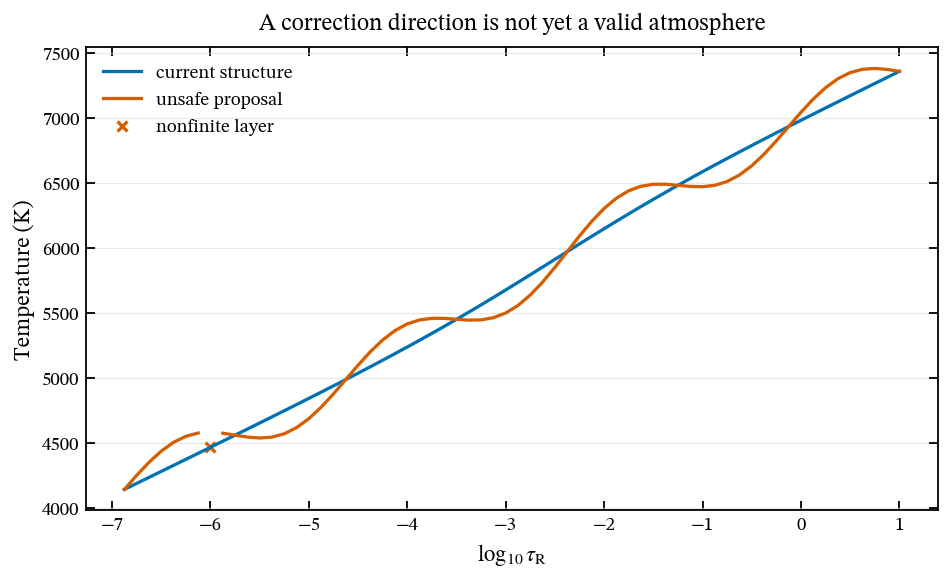

In [3]:
analytic = load_correction_inputs()
log_tau = np.log10(analytic["rosseland_optical_depth"])
old_temperature = analytic["temperature_k"]
unsafe_temperature = old_temperature + 180.0 * np.sin(
    np.linspace(0.0, 7.0 * np.pi, old_temperature.size)
)
unsafe_temperature[7] = np.nan

figure, axes = single_panel()
axes.plot(log_tau, old_temperature, label="current structure")
axes.plot(log_tau, unsafe_temperature, label="unsafe proposal")
axes.scatter(log_tau[7], old_temperature[7], marker="x",
             color=PAPER_COLORS["orange"], label="nonfinite layer")
axes.set(xlabel=r"$\log_{10}\tau_{\rm R}$",
         ylabel="Temperature (K)",
         title="A correction direction is not yet a valid atmosphere")
add_quiet_grid(axes, axis="y")
axes.legend()
plt.show()
plt.close(figure)


The oscillatory proposal has not earned a new structure. One layer
is undefined and several neighboring layers reverse their inward
trend.

The actual handoff is not that proposal and is not the analytic
fixture used below. It is the live 80-layer
`IterationFinalization` produced from Chapter 11's exact
`OpacityState`. The first Chapter 13 operation consumes its
`TemperatureCorrectionResult` through the canonical complete-state
remapper.


In [4]:
handoff = chapter12_handoff_checkpoint()
print(
    f"{handoff.finalization_type} -> "
    f"{handoff.correction_type} -> {handoff.remap_type}"
)
print("depth / frequency:",
      handoff.depth_count, handoff.frequency_count)
print("correction finite:",
      handoff.correction_result_finite)
print("corrected m positive and increasing:",
      handoff.correction_column_mass_positive,
      handoff.correction_column_mass_strictly_increasing)
print("remapped fields finite and m increasing:",
      handoff.remapped_fields_finite,
      handoff.remapped_column_mass_strictly_increasing)


IterationFinalization -> TemperatureCorrectionResult -> IterationRemap
depth / frequency: 80 30000
correction finite: True
corrected m positive and increasing: True True
remapped fields finite and m increasing: True True


The exact handoff makes the boundary executable. The controlled
analytic state now serves a narrower purpose: it exposes the
correction terms with a pinned comparison oracle. In both cases,
the production correction has two jobs—respond to the measured
energy imbalance and preserve a usable numerical state.

## 13.1 The residual is an integrated Eddington flux

Radiative transfer returns the integrated Eddington flux
\(H_{\rm rad}\). Convection contributes \(H_{\rm conv}\) in the
same internal scale. The target is

\[
H_\star=\frac{\sigma_{\rm SB}}{4\pi}T_{\rm eff}^4,
\qquad
\delta_H=100\,
  \frac{H_{\rm rad}+H_{\rm conv}-H_\star}{H_\star}.
\]

The factor \(4\pi\) matters: \(H\) is not the physical flux
\(F=4\pi H\). A negative \(\delta_H\) means the current layer
carries too little outward energy in this scale. That sign gives a
direction, but transfer is nonlocal, so no single local
proportionality can supply the complete update.


In [5]:
effective_temperature = float(analytic["effective_temperature"][0])
target_flux = float(
    analytic["target_integrated_eddington_flux"][0]
)
radiative_flux = analytic["integrated_eddington_flux"]
convective_flux = analytic["convective_flux"]
flux_error_percent = (
    100.0
    * (radiative_flux + convective_flux - target_flux)
    / target_flux
)

print(f"T_eff:                 {effective_temperature:.1f} K")
print(f"target H:              {target_flux:.6e}")
print(
    "raw total-flux error:  "
    f"{flux_error_percent.min():+.3f}% to "
    f"{flux_error_percent.max():+.3f}%"
)
print(
    "exact correction signature:",
    inspect.signature(apply_temperature_correction),
)


T_eff:                 5777.0 K
target H:              5.025262e+09
raw total-flux error:  -11.999% to +15.082%
exact correction signature: (state: 'TemperatureCorrectionState', *, mode: 'int', frequency_weight: 'float', column_mass: 'np.ndarray', total_opacity: 'np.ndarray', monochromatic_eddington_flux: 'np.ndarray', mean_intensity_minus_source: 'np.ndarray', monochromatic_optical_depth: 'np.ndarray', planck_source: 'np.ndarray', frequency_hz: 'float', h_over_kt: 'np.ndarray', temperature_k: 'np.ndarray', stimulated_emission: 'np.ndarray', scattering_fraction: 'np.ndarray', target_integrated_eddington_flux: 'float', effective_temperature: 'float', frequency_count: 'int', rosseland_optical_depth: 'np.ndarray | None' = None, rosseland_opacity: 'np.ndarray | None' = None, iteration_index: 'int' = 1, convection_enabled: 'bool | int' = False, convective_flux: 'np.ndarray | None' = None, previous_convective_flux: 'np.ndarray | None' = None, logarithmic_temperature_pressure_gradient: 'np.nd

## 13.2 Deep layers: diffusion converts a flux error into kelvin

Take the deep interior first, because there the argument closes
exactly. Far below the surface a photon's mean free path is tiny
compared with the distance over which the structure changes, so
radiation random-walks and transport becomes diffusive. The
Eddington closure \(K=J/3\) holds well, and the second moment
equation \(dK/d\tau_{\rm R}=H\) becomes

\[
\frac{dJ}{d\tau_{\rm R}}=3H.
\]

Deep layers are also strongly coupled to the gas, so \(J\to B\),
the frequency-integrated Planck function \(B=\sigma_{\rm SB}T^4/\pi\).
A correct atmosphere would therefore satisfy
\(dB/d\tau_{\rm R}=3H_\star\) at every depth. The pass we just ran
returned \(H(\tau_{\rm R})\) instead, so the accumulated error in
\(B\) by depth \(\tau_{\rm R}\) is

\[
\Delta B(\tau_{\rm R})
=3\int_0^{\tau_{\rm R}}
  \left[H_\star-H(\tau')\right]d\tau'.
\]

The integral is the important part. A flux error at one depth does
not misplace that layer alone; it misplaces every layer beneath it,
because each one is built on the gradient established above.
Converting from \(B\) to temperature with
\(dB/dT=4\sigma_{\rm SB}T^3/\pi\),

\[
\Delta T(\tau_{\rm R})
=\frac{3\pi}{4\sigma_{\rm SB}T^3}
 \int_0^{\tau_{\rm R}}
 \left[H_\star-H(\tau')\right]d\tau'.
\]

This is `flux_temperature_derivative`. Its sign is exactly the
intuition from §13.1: a layer carrying too little outward flux
needs a steeper gradient above it, which means heating everything
below.


## 13.3 Shallow layers: where that derivation fails

Every step above assumed the diffusion limit, and near the surface
each assumption breaks. The mean free path becomes comparable to
the scale height, photons escape instead of random-walking, and
\(J\) decouples from \(B\). The Eddington closure is no longer
accurate enough to convert a flux error into a temperature step.

What still holds is the statement of radiative equilibrium itself:
a layer in steady state must emit exactly what it absorbs,

\[
\int \kappa_\nu\left(J_\nu-S_\nu\right)d\nu=0,
\]

and the accumulator for that residual was built in §12.12. Now ask
how it responds to a temperature nudge. Raising \(T\) raises
\(S_\nu\) immediately through \(B_\nu\). It raises \(J_\nu\) only
indirectly, because \(J\) is the transfer solution driven by the
source everywhere, \(J=\Lambda[S]\).

Solving with the full \(\Lambda\) operator would be a dense,
expensive linear problem. Keeping only its diagonal
\(\Lambda_{dd}\) — the part of \(J\) at one depth that came from
the source at that same depth — turns the update into a local
Newton step:

\[
\Delta T\approx
\frac{\displaystyle\int \kappa_\nu (J_\nu-S_\nu)\,d\nu}
     {\displaystyle\left(1-\Lambda_{dd}\right)
      \int \kappa_\nu \frac{\partial B_\nu}{\partial T}\,d\nu}.
\]

This is `lambda_temperature_derivative`: cheap because only the
diagonal is retained, and adequate precisely where the flux
integral is not, because in optically thin layers the local term
dominates the response.

The outermost layer keeps neither mechanism. It has no material
above it, so its emergent flux is fixed by the boundary condition
rather than by an interior gradient, and it gets its own repair —
`surface_temperature_derivative`.

All three are linearizations of a nonlinear problem, which is why
no single pass is trusted to land. The safeguards of §13.5 exist to
keep a confident linear step from overshooting.


## 13.4 Three terms answer three depth regimes

The exact correction separates three temperature contributions.

- `flux_temperature_derivative` integrates the flux imbalance
  through Rosseland depth.
- `lambda_temperature_derivative` uses the local diagonal response
  of mean intensity in shallow, radiative layers.
- `surface_temperature_derivative` repairs the outer boundary
  flux.

The historical executable names end in `_derivative`, although the
returned arrays are temperature steps in kelvin. We retain those
names so the notation and implementation cannot drift apart.

The compact 64-layer input below is analytic. We first compute all
eleven fields locally. Only afterward does the checkpoint open its
comparison-only archive.


In [6]:
correction = correction_checkpoint()
result = correction.computed
result_fields = tuple(TemperatureCorrectionResult.__dataclass_fields__)

print("returned fields:", len(result_fields))
for name in result_fields:
    values = result[name]
    print(
        f"{name:34s} shape={str(values.shape):8s} "
        f"dtype={values.dtype}"
    )
print()
print("largest pinned-array difference:",
      correction.maximum_absolute_difference)
print("three-term raw identity:",
      correction.raw_three_term_identity)


returned fields: 11
temperature                        shape=(64,)    dtype=float64
flux_error_percent                 shape=(64,)    dtype=float64
flux_derivative                    shape=(64,)    dtype=float64
flux_temperature_derivative        shape=(64,)    dtype=float64
lambda_temperature_derivative      shape=(64,)    dtype=float64
surface_temperature_derivative     shape=(64,)    dtype=float64
temperature_correction             shape=(64,)    dtype=float64
flux_ratio                         shape=(64,)    dtype=float64
convective_flux                    shape=(64,)    dtype=float64
column_mass                        shape=(64,)    dtype=float64
column_mass_correction             shape=(64,)    dtype=float64

largest pinned-array difference: 0.0
three-term raw identity: True


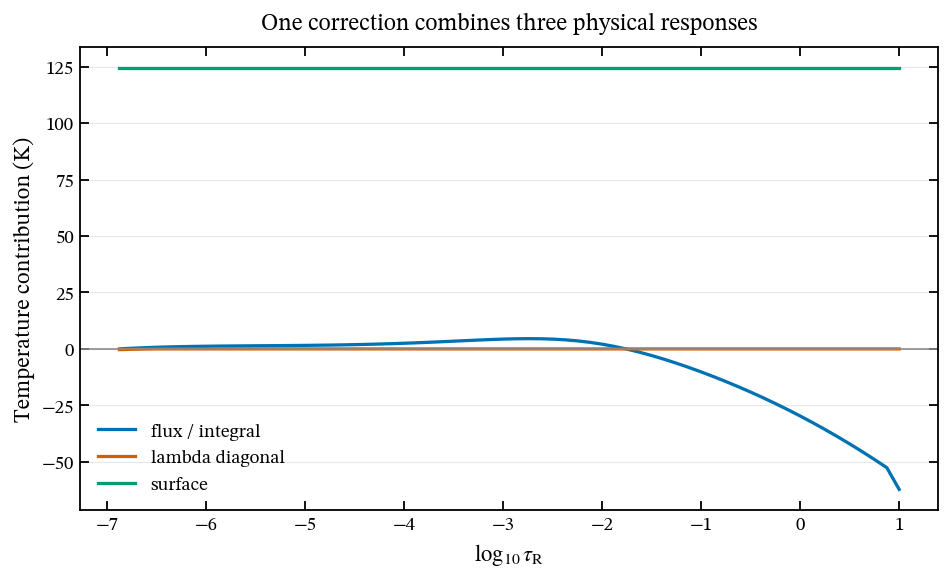

In [7]:
figure, axes = single_panel()
terms = (
    ("flux / integral", "flux_temperature_derivative", "blue"),
    ("lambda diagonal", "lambda_temperature_derivative", "orange"),
    ("surface", "surface_temperature_derivative", "green"),
)
for label, name, color in terms:
    axes.plot(
        log_tau,
        result[name],
        label=label,
        color=PAPER_COLORS[color],
    )
axes.axhline(0.0, color=PAPER_COLORS["grey"], linewidth=0.9)
axes.set(xlabel=r"$\log_{10}\tau_{\rm R}$",
         ylabel="Temperature contribution (K)",
         title="One correction combines three physical responses")
add_quiet_grid(axes, axis="y")
axes.legend()
plt.show()
plt.close(figure)


The constant surface term sets the broad positive offset in this
fixture. The flux term changes with depth, while the
lambda-diagonal term is restricted to shallow radiative layers.
Their sum is the *raw* correction before the returned temperature
is smoothed and constrained.

## 13.5 Safeguards are an ordered algorithm

Every term in §13.4 is a linearization, and §13.3 warned that
linearizations overshoot. A safeguard is not defensive programming
here; it is the part of the method that keeps a confident step from
producing a structure the next pass cannot even evaluate. Each of
these guards answers a specific failure:

1. **smooth the active convective flux after zeroing its first two
   layers** — mixing-length theory is least trustworthy exactly where
   the surface suppression policy of §12.22 applies, and a noisy
   convective flux would inject that noise straight into the energy
   residual;
2. **integrate the optical-depth correction and clamp it within**
   \([-\tau_{\rm R}/3,+\tau_{\rm R}/3]\) — the depth coordinate must
   stay ordered. A larger shift could make \(\tau_{\rm R}\)
   non-monotonic, which would not be a bad atmosphere so much as an
   uninterpretable one;
3. **limit the local lambda and surface steps using**
   \(T_{\rm eff}/25\) — these are the two terms built from a local
   Newton step, and the surface is where their linearization is
   weakest, so they are the ones most able to propose an absurd
   jump;
4. **combine the three temperature terms** — only now, once each
   contribution has been individually bounded, so that a later cap
   cannot disguise which term misbehaved;
5. **use the previous correction to damp oscillation** — successive
   substitution can overshoot and reverse on alternate passes.
   Averaging against the previous step is under-relaxation: it trades
   a little convergence speed for a trajectory that settles rather
   than rings;
6. **replace nonfinite proposals and require** \(T\ge1\) K — one NaN
   anywhere would propagate through the equation of state, opacity,
   and transfer on the next pass, so it must be contained at the
   moment it appears rather than diagnosed later;
7. **apply the configured local smoother** — the correction is
   computed depth by depth and can be rougher than any real
   atmosphere;
8. **walk outward from the inner boundary and require at least a
   one-kelvin rise inward** — temperature increasing inward is a
   physical requirement, not a preference, and the smoother in step 7
   can locally violate it.

The order carries as much of the method as the list does. Bounding
before combining keeps each term's failure visible; damping after
combining acts on the total step rather than on one component; and
the monotonic walk comes last because it is the only guard permitted
to have the final word about the returned structure. Reordering these
operations changes the trajectory.

One naming consequence follows: `temperature_correction` stores the
damped raw step from stage 5, while `temperature` stores the fully
safeguarded result from stage 8. They are deliberately not the same
quantity, and the plot below shows how far apart they can sit.


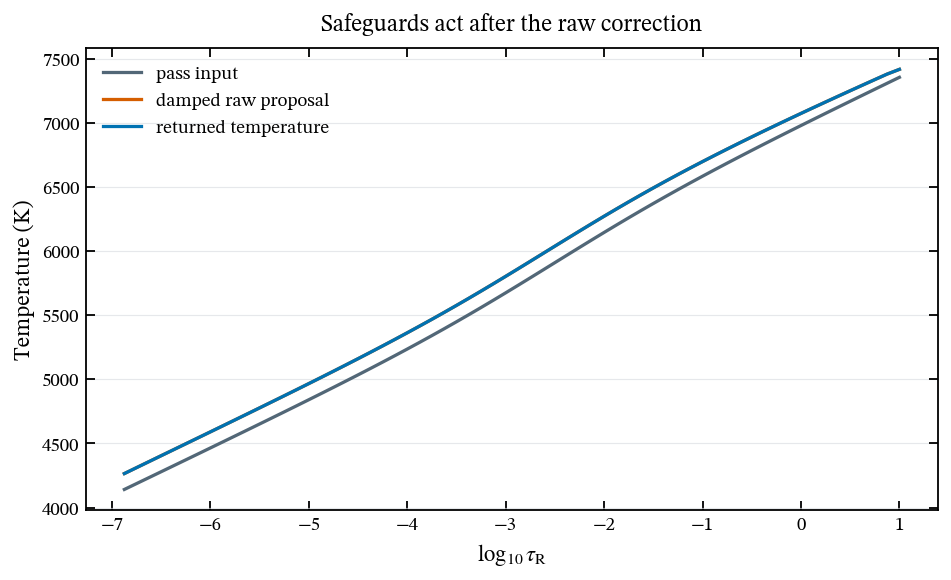

minimum inward rise: 36.901 K


In [8]:
raw_temperature = (
    correction.input_temperature
    + result["temperature_correction"]
)
safeguarded_temperature = result["temperature"]

figure, axes = single_panel()
axes.plot(log_tau, correction.input_temperature,
          label="pass input", color=PAPER_COLORS["slate"])
axes.plot(log_tau, raw_temperature,
          label="damped raw proposal", color=PAPER_COLORS["orange"])
axes.plot(log_tau, safeguarded_temperature,
          label="returned temperature", color=PAPER_COLORS["blue"])
axes.set(xlabel=r"$\log_{10}\tau_{\rm R}$",
         ylabel="Temperature (K)",
         title="Safeguards act after the raw correction")
add_quiet_grid(axes, axis="y")
axes.legend()
plt.show()
plt.close(figure)

print("minimum inward rise:",
      f"{correction.minimum_inward_temperature_rise_k:.3f} K")


The raw and returned curves are close but not identical. That
difference is essential for the column-mass update. The pressure
response compares the old temperature with
`temperature + temperature_correction`—the damped raw proposal,
not the later smoothed and monotonic curve. It solves old and new
total pressure on the standard grid, remaps their fractional
change back to the native grid, and applies

\[
\Delta m
  =m\,{\cal R}_{\tau\rightarrow m}
    \left(\frac{P_{\rm tot,new}}{P_{\rm tot,old}}-1\right).
\]

That operation moves the depth coordinate. Positive and strictly
increasing column mass are therefore checks, not assumptions.


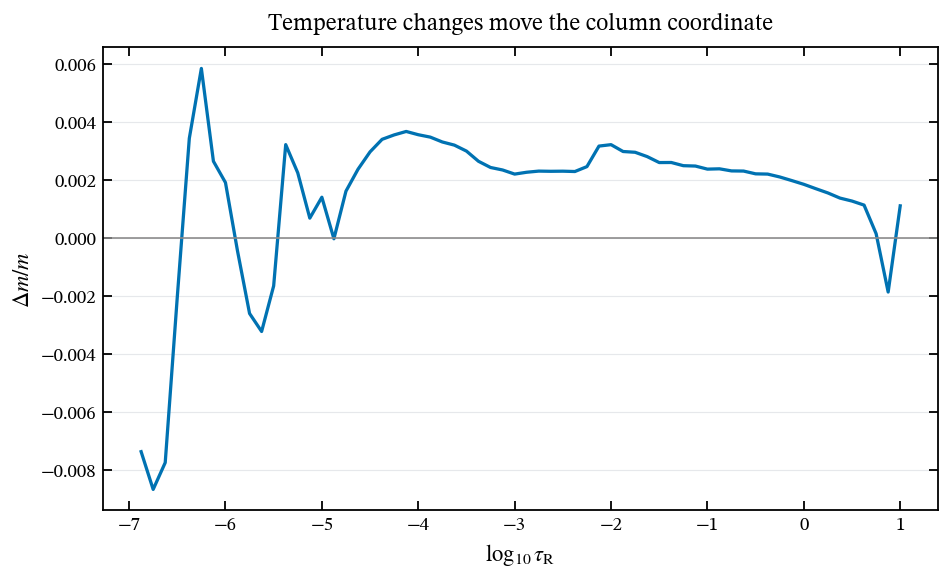

column mass positive: True
column mass strictly increasing: True


In [9]:
fractional_column_change = (
    result["column_mass_correction"] / analytic["column_mass"]
)
figure, axes = single_panel()
axes.plot(log_tau, fractional_column_change,
          color=PAPER_COLORS["blue"])
axes.axhline(0.0, color=PAPER_COLORS["grey"], linewidth=0.9)
axes.set(xlabel=r"$\log_{10}\tau_{\rm R}$",
         ylabel=r"$\Delta m / m$",
         title="Temperature changes move the column coordinate")
add_quiet_grid(axes, axis="y")
plt.show()
plt.close(figure)

print("column mass positive:",
      correction.column_mass_positive)
print("column mass strictly increasing:",
      correction.column_mass_strictly_increasing)


## 13.6 One state object contains two lifetimes

Transfer mode 1 resets four frequency accumulators at the start of
each pass. It must preserve two pieces of memory:
`previous_temperature_correction`, used to damp oscillation, and
`rosseland_opacity_table`, used by the pressure response. Replacing
the whole object each pass would erase both.


In [10]:
reset = reset_checkpoint()
print("reset each pass")
for name, total in zip(reset.reset_fields, reset.reset_sums):
    print(f"  {name:42s} sum after mode 1 = {total:.1f}")
print("carried")
for name in reset.carried_fields:
    print(" ", name)
print()
print("previous correction unchanged:",
      reset.previous_correction_unchanged)
print("same lookup object:",
      reset.lookup_same_object)
print("lookup entries unchanged:",
      reset.lookup_entry_count_unchanged)


reset each pass
  mean_intensity_minus_source_integral       sum after mode 1 = 0.0
  absorption_heating_derivative              sum after mode 1 = 0.0
  diagonal_lambda_accumulator                sum after mode 1 = 0.0
  integrated_eddington_flux                  sum after mode 1 = 0.0
carried
  previous_temperature_correction
  rosseland_opacity_table

previous correction unchanged: True
same lookup object: True
lookup entries unchanged: True


Previous-step damping is also branch-specific. Iteration 1 is
undamped. With convection disabled, a smaller same-sign current
step is multiplied by 1.25; a sign reversal is multiplied by 0.5.
These factors look counterintuitive until we remember their roles:
the first branch avoids stalling in the same direction, while the
second suppresses oscillation across zero.


In [11]:
damping = damping_checkpoint()
same_sign_error = np.max(np.abs(
    damping.same_sign - damping.same_sign_expected
))
sign_flip_error = np.max(np.abs(
    damping.sign_flip - damping.sign_flip_expected
))

print("same-sign branch maximum error:", same_sign_error)
print("sign-flip branch maximum error: ", sign_flip_error)
print(
    "example layer:",
    {
        "undamped": damping.undamped[20],
        "same_sign": damping.same_sign[20],
        "sign_flip": damping.sign_flip[20],
    },
)


same-sign branch maximum error: 0.0
sign-flip branch maximum error:  0.0
example layer: {'undamped': np.float64(123.61648330106893), 'same_sign': np.float64(154.52060412633617), 'sign_flip': np.float64(61.80824165053446)}


## 13.7 Remap the whole state before repeating

The correction is still on the current native
\(\tau_{\rm R}\) grid. A complete remap puts corrected column mass
and temperature, gas pressure, electron density, Rosseland opacity,
integrated radiation pressure, microturbulence, turbulent
pressure, radiative acceleration, convective flux, and convective
velocity on

\[
\tau_{{\rm R},i}^{\rm std}
  =10^{-6.875+0.125i}.
\]

No formatter or parser belongs here. The interior edge is

```text
correction -> complete remap -> next pass
```

On pass 1 the seed supplies gas pressure. From pass 2 onward,
pressure iteration may recompute it from the previous remapped
column mass, integrated radiation pressure, and turbulent
pressure. Populations and opacity are then recomputed. Catalog
*objects* may be reused, but their old opacity slab may not.

The exact full pass has fifteen ordered stages:

<figure>
  <img src="assets/schematics/textbook/ch13-exact-pass-orbit-v1.png"
       alt="Conceptual hand-sketched fifteen-station atmosphere-pass orbit from seed or prior remap through setup, populations, opacity, catalog lifecycle, accumulator reset, transfer, Rosseland and radiation finalization, lookup ingest, convection, correction, disabled diagnostics when needed, complete remap, carried state, and diagnostics, with the unquantized remap returning to the next pass and no quantization inside the loop.">
  <figcaption><strong>Conceptual pass-orbit
  schematic.</strong> Pass-local arrays reset where the source
  resets them; catalog handles, lookup history, the surface
  constant, and the unquantized complete remap cross their
  declared boundaries. Fixed-column quantization remains outside
  this orbit.</figcaption>
</figure>


In [12]:
plan = runner_patch_plan()
for index, stage in enumerate(plan["pass_order"], start=1):
    print(f"{index:2d}. {stage}")
print()
print("interior boundary:", plan["interior_edge"])
print("terminal boundary:", plan["terminal_edge"])
if plan["missing_symbols"]:
    print(
        "shared-runner seam still pending:",
        ", ".join(plan["missing_symbols"]),
    )
else:
    print("shared-runner seam: ready")


 1. seed copy or prior remap plus optional hydrostatic pressure
 2. pass-local setup with carried surface radiation pressure
 3. populations, molecules, internal energy, widths, and strengths
 4. continuum and line opacity
 5. first-pass catalog construction or later object reuse
 6. reset pass accumulators while history and lookup persist
 7. frequency-chunk transfer and fixed-order reduction
 8. Rosseland finalization
 9. radiation-pressure finalization and new surface constant
10. Rosseland lookup ingest
11. four EOS perturbations and convection when enabled
12. temperature and column-mass correction
13. disabled-convection diagnostics when needed, then complete remap
14. carry lookup and surface constant
15. structural and flux diagnostics, counter, return or terminal exit

interior boundary: correction -> complete remap -> next pass
terminal boundary: one fixed-column format/parse -> AtmosphereRunResult -> converged-only product rebuild
shared-runner seam: ready


The shared runner now contains this complete pass in the same
order. The separate checkpoints above remain useful because they
expose the correction and stopping contracts without inventing a
second one-pass API.

## 13.8 Structural convergence is a state machine

On the standard 80-layer grid, the deep norm uses the zero-based
slice `[39:L-5]`:

\[
\epsilon_{\rm deep}
  =\max_i\frac{|T_i^{\rm out}-T_i^{\rm in}|}
                  {|T_i^{\rm out}|}.
\]

Smaller arrays use every layer. The optional all-layer norm is

\[
\epsilon_{\rm all}
  =\max_i\frac{|T_i^{\rm out}-T_i^{\rm in}|}
  {\max(|T_i^{\rm in}|,|T_i^{\rm out}|,1\ {\rm K})}.
\]

Limits are strict `<`. A pass increments the consecutive counter
only after the minimum pass and only when every configured norm
passes. Any other pass resets it to zero.

Each of those choices is doing work. The deep slice drops the outer
thirty-nine layers because that is precisely the region §13.3
described as hardest: the correction there rests on a local Newton
step, the convective flux is policy-suppressed, and relative
temperature changes stay comparatively large long after the interior
has settled. Left in, those layers would dominate the norm and the
solver would never declare success. The innermost five are dropped
for the opposite reason — they are pinned by the deep boundary
condition rather than solved, so they carry no information about
whether the iteration has converged.

The norm is a maximum, not an average. An RMS over eighty layers can
report a comfortable number while one layer is still moving by
hundreds of kelvin; a maximum refuses to average that away. The
one-kelvin floor in the all-layer norm exists only to stop the
denominator collapsing where a temperature approaches zero.

Most importantly, convergence is *consecutive*. A single quiet pass
proves very little, because the under-relaxation of §13.5 makes a
damped oscillation cross through a small step on its way from one
side to the other. Requiring several successive quiet passes — and
resetting the counter to zero rather than decrementing it on any
failure — is what distinguishes a trajectory that has settled from
one that merely paused. The minimum-pass requirement closes the
matching hole at the start: a seed good enough to look converged
immediately has still not demonstrated that the physics agrees with
it.


In [13]:
base = np.linspace(4300.0, 7800.0, 80)
shallow_only = base.copy()
shallow_only[:39] += 100.0
deep_only = base.copy()
deep_only[39:-5] += 4.0

shallow_norm = deep_layer_relative_temperature_change(
    base, shallow_only
)
deep_norm = deep_layer_relative_temperature_change(
    base, deep_only
)
all_norm = max_normalized_column_delta(
    base, shallow_only, floor=1.0, symmetric=True
)

print("deep norm, shallow-only change:", shallow_norm)
print("deep norm, deep change:        ", deep_norm)
print("all-layer shallow change:      ", all_norm)


deep norm, shallow-only change: 0.0
deep norm, deep change:         0.000663146672934382
all-layer shallow change:       0.022727272727272728


In [14]:
control = iteration_control_checkpoint()
traces = {
    "minimum 3, two consecutive": control.standard_trace,
    "interrupted consecutive run": control.interrupted_trace,
    "stopping disabled": control.stopping_disabled_trace,
}
for label, trace in traces.items():
    print(label)
    print("  within limits:  ", trace.within_limits.tolist())
    print("  eligible:       ", trace.eligible.tolist())
    print("  counter:        ", trace.consecutive_count.tolist())
    print("  stopping pass:  ", trace.stopping_pass)
    print("  converged:      ", trace.converged)


minimum 3, two consecutive
  within limits:   [False, True, True, True]
  eligible:        [False, False, True, True]
  counter:         [0, 0, 1, 2]
  stopping pass:   4
  converged:       True
interrupted consecutive run
  within limits:   [False, True, False, True, True]
  eligible:        [False, True, True, True, True]
  counter:         [0, 1, 0, 1, 2]
  stopping pass:   5
  converged:       True
stopping disabled
  within limits:   [True, True, True, True, True]
  eligible:        [False, False, False, False, False]
  counter:         [0, 0, 0, 0, 0]
  stopping pass:   None
  converged:       False


The first trace stops at pass 4: pass 2 may be numerically small,
but the minimum is 3, so only passes 3 and 4 count. The interrupted
trace stops at pass 5 because pass 3 resets the counter. With
stopping disabled, a tiny norm never changes `converged` to true.

This Boolean describes a structural fixed point only. Median,
95th-percentile, and maximum absolute flux errors remain
diagnostics; they are not silently added to the stopping rule.

## 13.9 Parallel frequencies, sequential passes

Population depths and continuum frequencies contain independent
work. Transfer uses contiguous frequency chunks: each `prange`
chunk owns private accumulators, then chunks are reduced in
increasing order. Atmosphere passes cannot be parallel because
pass \(n+1\) consumes pass \(n\)'s remapped structure.

Both halves of that arrangement are deliberate. Private accumulators
mean no two threads ever write the same location, so the hot loop
needs no locking and no atomics. Reducing them in increasing chunk
order then costs nothing and buys reproducibility: floating-point
addition is not associative, so as §12.9 showed, a different grouping
moves the last bits. Fixing the order makes the result independent of
how the scheduler happened to finish the chunks — which is what lets
us treat a bitwise comparison against the pinned oracle as a
meaningful test rather than a coin flip.


In [15]:
chunks = chunk_checkpoint(start=0, stop=17, chunk_count=4)
print("bounds:", chunks.bounds.tolist())
for chunk in range(chunks.chunk_count):
    left, right = chunks.bounds[chunk : chunk + 2]
    print(
        f"chunk {chunk}: frequencies "
        f"[{int(left)}, {int(right)})"
    )
print("each frequency visited once:",
      chunks.covers_each_frequency_once)
print("reduction order:",
      chunks.reduction_order.tolist())


bounds: [0, 4, 8, 12, 17]
chunk 0: frequencies [0, 4)
chunk 1: frequencies [4, 8)
chunk 2: frequencies [8, 12)
chunk 3: frequencies [12, 17)
each frequency visited once: True
reduction order: [0, 1, 2, 3]


A fixed thread count fixes these boundaries and therefore the
reduction grouping. A different count may change the last few
bits even though each frequency contribution is unchanged. Strict
trajectory comparisons fix the thread count; alternate counts
require a measured tolerance.

## 13.10 Quantize once, at the terminal boundary

The external fixed-column atmosphere format rounds several fields.
That makes format/parse a numerical operator \(Q\), not cosmetic
output. Applying \(Q\) inside the loop would change the fixed-point
map. The runner therefore keeps remapped float64 arrays between
passes and applies \(Q\) exactly once after the loop.

<figure>
  <img src="assets/schematics/textbook/ch13-terminal-quantization-gate-v1.png"
       alt="Conceptual hand-sketched terminal boundary in which the physical iteration returns an unquantized complete remap, exit crosses one format-then-parse quantization gate, result columns use the terminal quantized state, debug retains the last unquantized remap, and only convergence permits populations to be rebuilt from quantized columns into a schema-v4 physical product.">
  <figcaption><strong>Conceptual terminal-boundary
  schematic.</strong> Iteration carries an unquantized complete
  remap. One terminal format/parse operation defines result
  columns; debug preserves the last unquantized remap, while
  schema v4 is rebuilt from quantized columns and promoted only
  after structural convergence.</figcaption>
</figure>


In [16]:
quantization = quantization_checkpoint()
quantization_delta = (
    quantization.quantized_temperature
    - quantization.input_temperature
)
print("normal terminal format/parse calls:",
      quantization.terminal_format_parse_calls)
print("additional idempotence probe calls:",
      quantization.idempotence_probe_format_parse_calls)
print("largest temperature rounding (K):",
      np.max(np.abs(quantization_delta)))
print("operator idempotent:",
      quantization.idempotent)
print(
    "first three input -> quantized:",
    list(zip(
        quantization.input_temperature[:3],
        quantization.quantized_temperature[:3],
    )),
)


normal terminal format/parse calls: 1
additional idempotence probe calls: 1
largest temperature rounding (K): 0.036264593550185964
operator idempotent: True
first three input -> quantized: [(np.float64(4264.833349575579), np.float64(4264.8)), (np.float64(4311.46373540645), np.float64(4311.5)), (np.float64(4357.987070127888), np.float64(4358.0))]


Terminal quantization occurs even when a fixed budget ends without
structural convergence. Product promotion is stricter: a requested
schema-v4 atmosphere is written only when `converged=True`, and
its synthesis populations are rebuilt from the terminal quantized
columns. The optional debug snapshot instead retains the last
unquantized remap and last runtime state for triage. A debug file
is not the release product.

## 13.11 Compilation and prewarming have their own state

`configure_numba_cache` honors an existing `NUMBA_CACHE_DIR`,
otherwise `PAYNE_ZERO_NUMBA_CACHE_DIR`, otherwise its default
persistent location. First compilation, a warm call in the same
process, and a fresh process after prewarm are different timing
regimes.

With the complete shared runner staged, the prewarm entry point is
executable. This checkpoint verifies cache precedence and branch
inventory; a later performance pass will record representative
cold-process, warm-process, and post-prewarm timings separately.


In [17]:
cache = cache_contract_checkpoint()
prewarm = prewarm_contract_checkpoint()
outputs = output_contract_checkpoint()
print("existing NUMBA_CACHE_DIR wins:",
      cache.existing_numba_cache)
print("then PAYNE_ZERO_NUMBA_CACHE_DIR:",
      cache.requested_payne_zero_cache)
print("then default:",
      cache.default_cache)
print("complete runner symbols available:",
      list(cache.runner_symbols_available))
print("complete runner symbols pending:",
      list(cache.runner_symbols_missing))
print("full prewarm executable:",
      cache.prewarm_executable)
print("prewarm branches:",
      list(prewarm.branch_names))
print("passes per branch:",
      prewarm.representative_iterations_per_branch)
print("diagnostics_path written:",
      outputs.diagnostics_path_written)
print("product population source:",
      outputs.product_population_source)


existing NUMBA_CACHE_DIR wins: /tmp/chapter13-existing-numba
then PAYNE_ZERO_NUMBA_CACHE_DIR: /tmp/chapter13-requested
then default: /Users/ysting/.cache/payne-zero/numba-atmosphere
complete runner symbols available: ['TransferAccumulation', 'IterationFinalization', 'IterationRemap', 'AtmosphereRunResult', 'finalize_transfer_state', 'remap_finalized_iteration_state', 'finalize_remapped_iteration', 'run_atmosphere_model']
complete runner symbols pending: []
full prewarm executable: True
prewarm branches: ['hot', 'sun', 'giant', 'sun_atomic_only']
passes per branch: 1
diagnostics_path written: False
product population source: final_fixed_column_quantized_arrays


## 13.12 Chapter summary

1. The energy residual compares radiative plus convective
   Eddington flux with
   \(H_\star=\sigma_{\rm SB}T_{\rm eff}^4/(4\pi)\).
2. The exact temperature correction combines flux/integral,
   lambda-diagonal, and surface terms in a fixed numerical order.
3. Previous-step damping, finite replacement, smoothing, and the
   inward-rise rule make the returned temperature a safeguarded
   structure, not merely the raw three-term sum.
4. Column mass responds through old/new total pressure evaluated
   from the damped raw correction.
5. A complete remap places every carried field on one standard
   Rosseland grid; no fixed-column quantization occurs between
   passes.
6. Accumulators reset each pass, while correction history, the
   Rosseland lookup, catalog handles, radiation-pressure support,
   and the surface constant are carried according to their exact
   lifetimes.
7. Structural convergence uses declared deep and optional
   all-layer norms, minimum-pass eligibility, and consecutive
   qualifying passes. It is not flux or scientific acceptance.
8. Frequency chunks may run in parallel with private state and
   ordered reduction; atmosphere passes remain sequential.
9. One terminal format/parse produces the public quantized
   atmosphere. Only a structurally converged result may promote a
   schema-v4 product rebuilt from those terminal columns.

### Next: enter the solver's basin without changing the solver

We can now judge one explicit seed by an exact physical update and
a precise structural stopping rule. Cool, high-gravity,
molecule-rich states may still start outside a reliable basin.
[Chapter 14 learns where to start, while every candidate must
return to this unchanged physical loop for the
answer.](/reader.html?ch=14)
